<a href="https://colab.research.google.com/github/alireza1420/stargazer-prediction-pipeline/blob/carolines-neural-net/Kopia_av_scaling_3000_repos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import requests
import json
import time

GITHUB_TOKEN = 'github_pat_'
HEADERS = {'Authorization': f'token {GITHUB_TOKEN}'}

# Intervaller med olika created-datum för att kringgå GitHubs 1000-resultatgräns
created_intervals = [
    ("<2015-01-01"),
    ("2015-01-01..2016-01-01"),
    ("2016-01-01..2017-01-01"),
    ("2017-01-01..2018-01-01"),
    ("2018-01-01..2019-01-01"),
    ("2019-01-01..2020-01-01"),
]

def fetch_segmented_top_repos(created_filter):
    per_page = 100
    repos = []

    for page in range(1, 11):  # Max 1000 repos per segment
        query = f"stars:>0 created:{created_filter}"
        url = f"https://api.github.com/search/repositories?q={query}&sort=stars&order=desc&page={page}&per_page={per_page}"

        for attempt in range(3):  # Retry-mekanik
            response = requests.get(url, headers=HEADERS)
            if response.status_code == 200:
                break
            print(f"Attempt {attempt + 1}: Error {response.status_code} on page {page} for created:{created_filter}")
            time.sleep(3)

        if response.status_code != 200:
            print(f"Skipping page {page} for created:{created_filter}")
            break

        data = response.json()
        items = data.get('items', [])
        if not items:
            break

        repos.extend(items)
        print(f"Fetched {len(items)} repos for created:{created_filter} (page {page})")
        time.sleep(1)

    return repos

# Hämta och kombinera
all_repos = []
for interval in created_intervals:
    repos = fetch_segmented_top_repos(interval)
    all_repos.extend(repos)

# Ta bort dubbletter (baserat på repo-ID)
unique_repos = {repo['id']: repo for repo in all_repos}
final_repo_list = list(unique_repos.values())

# Spara till JSON
with open("github_top_segmented_repos.json", "w", encoding="utf-8") as f:
    json.dump(final_repo_list, f, ensure_ascii=False, indent=4)

print(f"Total unique repos collected: {len(final_repo_list)}")


Attempt 1: Error 504 on page 1 for created:<2015-01-01
Fetched 100 repos for created:<2015-01-01 (page 1)
Attempt 1: Error 504 on page 2 for created:<2015-01-01
Fetched 100 repos for created:<2015-01-01 (page 2)
Fetched 100 repos for created:<2015-01-01 (page 3)
Attempt 1: Error 504 on page 4 for created:<2015-01-01
Attempt 2: Error 504 on page 4 for created:<2015-01-01
Fetched 100 repos for created:<2015-01-01 (page 4)
Fetched 100 repos for created:<2015-01-01 (page 5)
Fetched 100 repos for created:<2015-01-01 (page 6)
Fetched 100 repos for created:<2015-01-01 (page 7)
Fetched 100 repos for created:<2015-01-01 (page 8)
Attempt 1: Error 504 on page 9 for created:<2015-01-01
Attempt 2: Error 504 on page 9 for created:<2015-01-01
Fetched 100 repos for created:<2015-01-01 (page 9)
Fetched 100 repos for created:<2015-01-01 (page 10)
Fetched 100 repos for created:2015-01-01..2016-01-01 (page 1)
Fetched 100 repos for created:2015-01-01..2016-01-01 (page 2)
Fetched 100 repos for created:2015-

In [ ]:
import requests
import json
import time

# GitHub auth
GITHUB_TOKEN = 'github_pat_'
HEADERS = {'Authorization': f'token {GITHUB_TOKEN}'}

intervals = [
    (10000, 999999),
    (7000, 9999),
    (5000, 6999),
    (4000, 4999),
    (3000, 3999),
    (2000, 2999),
    (1500, 1999),
    (1200, 1499),
    (1000, 1199)
]

def get_repositories_by_stars(min_stars, max_stars):
    all_repos = []
    per_page = 100

    for page in range(1, 11):  # 10 sidor x 100 = max 1000 per intervall
        query = f"stars:{min_stars}..{max_stars}"
        url = f"https://api.github.com/search/repositories?q={query}&sort=stars&order=desc&page={page}&per_page={per_page}"
        response = requests.get(url, headers=HEADERS)

        if response.status_code != 200:
            print(f"Error {response.status_code} for interval {min_stars}-{max_stars}, page {page}")
            break

        data = response.json()
        items = data.get('items', [])
        if not items:
            break

        all_repos.extend(items)
        print(f"Fetched {len(all_repos)} repos from stars {min_stars}-{max_stars} (page {page})")
        time.sleep(1)  # Avoid rate-limiting

    return all_repos

all_collected_repos = []

for min_stars, max_stars in intervals:
    repos = get_repositories_by_stars(min_stars, max_stars)
    all_collected_repos.extend(repos)

unique_repos = {repo['id']: repo for repo in all_collected_repos}
final_repo_list = list(unique_repos.values())

# Spara som JSON
with open('github_top_10000_repos.json', 'w', encoding='utf-8') as f:
    json.dump(final_repo_list, f, ensure_ascii=False, indent=4)

print(f"Total unique repos collected: {len(final_repo_list)}")


Fetched 100 repos from stars 50-75 (page 1)
Fetched 200 repos from stars 50-75 (page 2)
Error 504 for interval 50-75, page 3
Error 504 for interval 76-100, page 1
Error 504 for interval 101-150, page 1
Error 504 for interval 151-200, page 1
Error 504 for interval 201-300, page 1
Error 504 for interval 301-400, page 1
Error 504 for interval 401-500, page 1
Error 504 for interval 501-600, page 1
Error 504 for interval 601-700, page 1
Error 504 for interval 701-800, page 1
Error 504 for interval 801-900, page 1
Error 504 for interval 901-1000, page 1
Error 504 for interval 1001-1200, page 1
Error 504 for interval 1201-1500, page 1
Error 504 for interval 1501-1800, page 1


KeyboardInterrupt: 

In [ ]:
import json
# load the row data
with open('github_top_segmented_repos.json', 'r', encoding='utf-8') as f:
    top_repos_loaded = json.load(f)

print(type(top_repos_loaded))  # <class 'list'>
print(type(top_repos_loaded[0]))  # <class 'dict'>

<class 'list'>
<class 'dict'>


In [ ]:
import re
import requests
import pandas as pd

GITHUB_TOKEN = 'github_pat_' # Paste your token
HEADERS = {'Authorization': f'token {GITHUB_TOKEN}'}
def get_count_with_pagination(url):
    try:
        first_page_url = f"{url}?per_page=1&page=1"
        response = requests.get(first_page_url, headers=HEADERS)

        if response.status_code != 200:
            return 0

        # Parse Link header to get the last page number
        link_header = response.headers.get('Link', '')
        match = re.search(r'page=(\d+)>; rel="last"', link_header)

        if match:
            return int(match.group(1))
        else:
            # If no pagination, return the count of items in the response
            return len(response.json())  # 0 或 1
    except:
        return 0

def get_contributor_count(url):
    url = f"{url}?anon=true&per_page=1&page=1002"  # Use a very large page number to trick GitHub into returning to the Link header

    try:
        response = requests.get(url, headers=HEADERS)
        if response.status_code != 200:
            return 0

        # Parse Link header to get the last page number
        link_header = response.headers.get('Link', '')
        match = re.search(r'page=(\d+)>; rel="last"', link_header)
        if match:
            last_page = int(match.group(1))
            return last_page
        else:
            # If no pagination, return the count of items in the response
            data = response.json()
            return len(data) if isinstance(data, list) else 0

    except Exception as e:
        return 0

def get_readme_size(repo_full_name):
    try:
        url = f'https://api.github.com/repos/{repo_full_name}/readme'
        response = requests.get(url, headers=HEADERS)
        if response.status_code == 200:
            return response.json().get('size', 0)
    except:
        pass
    return 0

def extract_features(repo_data):
    features = {
        'name': repo_data['name'],
        'full_name': repo_data['full_name'],
        'stars': repo_data['stargazers_count'],
        'forks': repo_data['forks_count'],
        'watchers': repo_data['watchers_count'],
        'open_issues': repo_data['open_issues_count'],
        'size': repo_data['size'],
        'has_wiki': int(repo_data['has_wiki']),
        'has_projects': int(repo_data['has_projects']),
        'has_downloads': int(repo_data['has_downloads']),
        'is_fork': int(repo_data['fork']),
        'archived': int(repo_data['archived']),
        'language': repo_data['language'],
        'license': repo_data['license']['key'] if repo_data['license'] else None,
        'created_at': repo_data['created_at'],
        'updated_at': repo_data['updated_at'],
        'pushed_at': repo_data['pushed_at'],

        # New features
        'has_description': int(bool(repo_data['description'])),
        'has_homepage': int(bool(repo_data['homepage'])),
        'topic_count': len(repo_data['topics']) if 'topics' in repo_data and isinstance(repo_data['topics'], list) else 0,
        'has_discussions': int(repo_data.get('has_discussions', False)),
        'is_template': int(repo_data.get('is_template', False)),
        'allow_forking': int(repo_data.get('allow_forking', True)),
        'visibility': repo_data.get('visibility', 'public'),

        # Counts with pagination
        'subscribers_count': get_count_with_pagination(repo_data['subscribers_url']),
        'contributors_count': get_contributor_count(repo_data['contributors_url']),
        'commits_count': get_count_with_pagination(repo_data['commits_url'].split('{')[0]),
        'readme_size': get_readme_size(repo_data['full_name'])
    }
    return features

# Process all repositories
c=1
features_list = []
for repo in top_repos_loaded:
    features = extract_features(repo)
    features_list.append(features)
    print(c)
    c+=1
    print(features)

features_df = pd.DataFrame(features_list)
features_df.to_csv('github_repo_features_new.csv', index=False)

# load data
df = pd.read_csv('github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])


# Parse and normalize time-related features
date = pd.to_datetime("2025-5-17")
df["project_age"] = (date.date() - df["created_at"].dt.date).apply(lambda x: x.days)
df["days_since_update"] = (date.date() - df["updated_at"].dt.date).apply(lambda x: x.days)
df["days_since_push"] = (date.date() - df["pushed_at"].dt.date).apply(lambda x: x.days)


# Handle missing values
df["license"] = df["license"].fillna("None")
df["language"] = df["language"].fillna("Unknown")

# Derived rate-based features
df["forks_per_day"] = df["forks"] / (df["project_age"] + 1)
df["issues_per_day"] = df["open_issues"] / (df["project_age"] + 1)
df["update_rate"] = 1 / (1 + df["days_since_update"])



1
{'name': 'freeCodeCamp', 'full_name': 'freeCodeCamp/freeCodeCamp', 'stars': 418855, 'forks': 40205, 'watchers': 418855, 'open_issues': 312, 'size': 499328, 'has_wiki': 0, 'has_projects': 1, 'has_downloads': 1, 'is_fork': 0, 'archived': 0, 'language': 'TypeScript', 'license': 'bsd-3-clause', 'created_at': '2014-12-24T17:49:19Z', 'updated_at': '2025-05-26T07:14:14Z', 'pushed_at': '2025-05-25T17:58:19Z', 'has_description': 1, 'has_homepage': 1, 'topic_count': 16, 'has_discussions': 0, 'is_template': 0, 'allow_forking': 1, 'visibility': 'public', 'subscribers_count': 8573, 'contributors_count': 5945, 'commits_count': 38364, 'readme_size': 32109}
2
{'name': 'awesome', 'full_name': 'sindresorhus/awesome', 'stars': 362183, 'forks': 29168, 'watchers': 362183, 'open_issues': 40, 'size': 1495, 'has_wiki': 0, 'has_projects': 0, 'has_downloads': 1, 'is_fork': 0, 'archived': 0, 'language': None, 'license': 'cc0-1.0', 'created_at': '2014-07-11T13:42:37Z', 'updated_at': '2025-05-26T07:14:18Z', 'pus

KeyboardInterrupt: 

In [ ]:
# load data
df = pd.read_csv('github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])

In [ ]:
df.head(5)

,name,full_name,stars,forks,watchers,open_issues,size,has_wiki,has_projects,has_downloads,...,has_homepage,topic_count,has_discussions,is_template,allow_forking,visibility,subscribers_count,contributors_count,commits_count,readme_size
0,acorn-cache,acorncache/acorn-cache,100,8,100,0,114,1,1,1,...,0,0,0,0,1,public,5,4,137,9493
1,mini-store,yesmeck/mini-store,100,13,100,1,55,1,1,1,...,0,0,0,0,1,public,6,7,52,2691
2,bifrost,uswitch/bifrost,100,15,100,0,58,1,1,1,...,0,0,0,0,1,public,49,6,58,2717
3,awesome-newsroom-tech,loganmeetsworld/awesome-newsroom-tech,100,10,100,0,92,1,1,1,...,0,5,0,0,1,public,5,7,42,16979
4,XCSnippetr,dzenbot/XCSnippetr,100,3,100,3,4416,0,0,1,...,0,0,0,0,1,public,6,5,72,3404


In [ ]:
# Features of the dataset
print(df.columns)
# Number of Features
len(df.columns)

Index(['name', 'full_name', 'stars', 'forks', 'watchers', 'open_issues',
       'size', 'has_wiki', 'has_projects', 'has_downloads', 'is_fork',
       'archived', 'language', 'license', 'created_at', 'updated_at',
       'pushed_at', 'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 'allow_forking', 'visibility',
       'subscribers_count', 'contributors_count', 'commits_count',
       'readme_size'],
      dtype='object')


28

In [ ]:
# Parse and normalize time-related features
date = pd.to_datetime("2025-5-17")
df["project_age"] = (date.date() - df["created_at"].dt.date).apply(lambda x: x.days)
df["days_since_update"] = (date.date() - df["updated_at"].dt.date).apply(lambda x: x.days)
df["days_since_push"] = (date.date() - df["pushed_at"].dt.date).apply(lambda x: x.days)


# Handle missing values
df["license"] = df["license"].fillna("None")
df["language"] = df["language"].fillna("Unknown")

# Derived rate-based features
df["forks_per_day"] = df["forks"] / (df["project_age"] + 1)
df["issues_per_day"] = df["open_issues"] / (df["project_age"] + 1)
df["update_rate"] = 1 / (1 + df["days_since_update"])

# Replace inf with NaN and drop rows with NaN
# df.replace([np.inf, -np.inf], np.nan, inplace=True)
# df.dropna(inplace=True)

In [ ]:
print(df[['stars', 'forks']].corr())

          stars     forks
stars  1.000000  0.183505
forks  0.183505  1.000000


In [ ]:
# Update of dataframe
df.head()

,name,full_name,stars,forks,watchers,open_issues,size,has_wiki,has_projects,has_downloads,...,subscribers_count,contributors_count,commits_count,readme_size,project_age,days_since_update,days_since_push,forks_per_day,issues_per_day,update_rate
0,acorn-cache,acorncache/acorn-cache,100,8,100,0,114,1,1,1,...,5,4,137,9493,3382,1135,2952,0.002365,0.000000,0.000880
1,mini-store,yesmeck/mini-store,100,13,100,1,55,1,1,1,...,6,7,52,2691,2765,630,1233,0.004700,0.000362,0.001585
2,bifrost,uswitch/bifrost,100,15,100,0,58,1,1,1,...,49,6,58,2717,3998,153,2101,0.003751,0.000000,0.006494
3,awesome-newsroom-tech,loganmeetsworld/awesome-newsroom-tech,100,10,100,0,92,1,1,1,...,5,7,42,16979,2055,103,1690,0.004864,0.000000,0.009615
4,XCSnippetr,dzenbot/XCSnippetr,100,3,100,3,4416,0,0,1,...,6,5,72,3404,3590,86,2944,0.000835,0.000835,0.011494


In [ ]:
df.columns

Index(['name', 'full_name', 'stars', 'forks', 'watchers', 'open_issues',
       'size', 'has_wiki', 'has_projects', 'has_downloads', 'is_fork',
       'archived', 'language', 'license', 'created_at', 'updated_at',
       'pushed_at', 'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 'allow_forking', 'visibility',
       'subscribers_count', 'contributors_count', 'commits_count',
       'readme_size', 'project_age', 'days_since_update', 'days_since_push',
       'forks_per_day', 'issues_per_day', 'update_rate'],
      dtype='object')

In [ ]:
A = [
            'stars', 'forks', 'watchers', 'open_issues',
            'size', 'topic_count', 'subscribers_count',
            'contributors_count', 'commits_count', 'readme_size',
            'project_age', 'days_since_update', 'days_since_push',
            'forks_per_day', 'issues_per_day', 'update_rate','has_wiki', 'has_projects', 'has_downloads', 'is_fork',
            'archived', 'language', 'license', 'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 'allow_forking', 'visibility'
        ]
for i in df.columns:
    if i not in A:
        print(i)

name
full_name
created_at
updated_at
pushed_at


In [ ]:
!pip install catboost ngboost xgboost lightgbm

# Optional packages (install as needed)
!pip install h2o tpot auto-sklearn prophet pygam interpret  # For specialized models

# If you wanst rule-based models
!pip install rulefit

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 11.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=cf47aed7b9239580a2c733901de5e346ab86ccea11ccb100461a60f771947c34
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 50.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.7 MB/s eta 0:00:0

In [ ]:
!pip install --upgrade xgboost
!pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 2.9 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.4
    Uninstalling xgboost-2.1.4:
      Successfully uninstalled xgboost-2.1.4


In [ ]:
!python.exe -m pip install --upgrade pip

/bin/bash: line 1: python.exe: command not found


# Pipeline

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                             AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor)
from sklearn.svm import SVR, NuSVR, LinearSVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


from sklearn.linear_model import (HuberRegressor, QuantileRegressor,
                                BayesianRidge, ARDRegression,
                                PassiveAggressiveRegressor, TheilSenRegressor,
                                OrthogonalMatchingPursuit, RANSACRegressor)
from sklearn.ensemble import (HistGradientBoostingRegressor,
                            StackingRegressor, VotingRegressor)
from sklearn.neighbors import RadiusNeighborsRegressor
from catboost import CatBoostRegressor
from ngboost import NGBRegressor  # For probabilistic forecasting



import joblib
import os


class GitHubRepoPreprocessor:
    """Custom preprocessing pipeline for GitHub repository metadata."""

    def __init__(self, reference_date=None):
        self.date = reference_date or datetime(2025, 5, 17)
        self.features = [
            'forks', 'open_issues',
       'size', 'has_wiki', 'has_projects', 'has_downloads',
       'archived', 'language', 'license',
       'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template',
       'subscribers_count', 'contributors_count', 'commits_count',
       'readme_size', 'project_age', 'days_since_push',
       'forks_per_day', 'issues_per_day'
        ] # delete 'watchers', 'is_fork', 'allow_forking', 'visibility', 'days_since_update' and 'update_rate'
        self.numeric_features = [
            'forks', 'open_issues',
            'size', 'topic_count', 'subscribers_count',
            'contributors_count', 'commits_count', 'readme_size',
            'project_age', 'days_since_push',
            'forks_per_day', 'issues_per_day'
        ]
        self.categorical_features = ["language", "license"]
        self.column_transformer = None

    def transform(self, df):
        # Parse and normalize time-related features
        df["project_age"] = (self.date.date() - df["created_at"].dt.date).apply(lambda x: x.days)
        df["days_since_update"] = (self.date.date() - df["updated_at"].dt.date).apply(lambda x: x.days)
        df["days_since_push"] = (self.date.date() - df["pushed_at"].dt.date).apply(lambda x: x.days)

        # Handle missing values
        df["license"] = df["license"].fillna("None")
        df["language"] = df["language"].fillna("Unknown")

        # Derived rate-based features
        df["forks_per_day"] = df["forks"] / (df["project_age"] + 1)
        df["issues_per_day"] = df["open_issues"] / (df["project_age"] + 1)
        df["update_rate"] = 1 / (1 + df["days_since_update"])

        return df[self.features], df["stars"]

    def get_preprocessor(self):
        """Construct and return a fitted ColumnTransformer"""
        self.column_transformer = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), self.numeric_features),
                ("cat", OneHotEncoder(handle_unknown="ignore"), self.categorical_features)
            ]
        )
        return self.column_transformer


def train_and_evaluate_models(df, save_path="best_model_cv.pkl"):
    """Train multiple regressors and save the best performing one."""
    preprocessor = GitHubRepoPreprocessor()
    X, y = preprocessor.transform(df)

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Preprocessing pipeline
    processor = preprocessor.get_preprocessor()

    # Candidate models
    models = {
        # Linear Models
        'Linear Regression': LinearRegression(),
        'Ridge (α=0.1)': Ridge(alpha=0.1),
        'Ridge (α=0.5)': Ridge(alpha=0.5),
        'Ridge (α=1.0)': Ridge(alpha=1.0),
        'Ridge (α=5.0)': Ridge(alpha=5.0),
        'Lasso (α=0.001)': Lasso(alpha=0.001),
        'Lasso (α=0.01)': Lasso(alpha=0.01),
        'Lasso (α=0.1)': Lasso(alpha=0.1),
        'ElasticNet (α=0.001)': ElasticNet(alpha=0.001, l1_ratio=0.5),
        'ElasticNet (α=0.01)': ElasticNet(alpha=0.01, l1_ratio=0.3),
        'ElasticNet (α=0.1)': ElasticNet(alpha=0.1, l1_ratio=0.7),
        'Huber Regressor (ϵ=1.35)': HuberRegressor(epsilon=1.35),
        'Huber Regressor (ϵ=2.0)': HuberRegressor(epsilon=2.0),
        'Quantile Regressor (α=0.5)': QuantileRegressor(quantile=0.5),
        'Quantile Regressor (α=0.9)': QuantileRegressor(quantile=0.9),
        'Bayesian Ridge': BayesianRidge(),
        'ARD Regression': ARDRegression(),
        'Passive Aggressive Regressor': PassiveAggressiveRegressor(random_state=42),
        'Theil-Sen Regressor': TheilSenRegressor(random_state=42),
        'Orthogonal Matching Pursuit': OrthogonalMatchingPursuit(),
        'RANSAC Regressor': RANSACRegressor(random_state=42),

        # Tree-based Models
        'Decision Tree (max_depth=3)': DecisionTreeRegressor(max_depth=3, random_state=42),
        'Decision Tree (max_depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
        'Decision Tree (max_depth=10)': DecisionTreeRegressor(max_depth=10, random_state=42),
        'Decision Tree (max_depth=None)': DecisionTreeRegressor(max_depth=None, random_state=42),
        'Decision Tree (min_samples_leaf=5)': DecisionTreeRegressor(min_samples_leaf=5, random_state=42),
        'Decision Tree (min_samples_split=10)': DecisionTreeRegressor(min_samples_split=10, random_state=42),
        'Decision Tree (max_features=sqrt)': DecisionTreeRegressor(max_features='sqrt', random_state=42),
        'Decision Tree (max_features=log2)': DecisionTreeRegressor(max_features='log2', random_state=42),

        # Ensemble Methods
        'Random Forest (n=50)': RandomForestRegressor(n_estimators=50, random_state=42),
        'Random Forest (n=100)': RandomForestRegressor(n_estimators=100, random_state=42),
        'Random Forest (n=200)': RandomForestRegressor(n_estimators=200, random_state=42),
        'Random Forest (n=300)': RandomForestRegressor(n_estimators=300, random_state=42),
        'Random Forest (max_depth=5)': RandomForestRegressor(max_depth=5, random_state=42),
        'Random Forest (max_depth=10)': RandomForestRegressor(max_depth=10, random_state=42),
        'Random Forest (max_features=sqrt)': RandomForestRegressor(max_features='sqrt', random_state=42),
        'Random Forest (max_features=log2)': RandomForestRegressor(max_features='log2', random_state=42),
        'Random Forest (min_samples_leaf=5)': RandomForestRegressor(min_samples_leaf=5, random_state=42),
        'Random Forest (bootstrap=False)': RandomForestRegressor(bootstrap=False, random_state=42),


        # Gradient Boosting
        'Gradient Boosting (n=50)': GradientBoostingRegressor(n_estimators=50, random_state=42),
        'Gradient Boosting (n=100)': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting (n=200)': GradientBoostingRegressor(n_estimators=200, random_state=42),
        'Gradient Boosting (learning_rate=0.01)': GradientBoostingRegressor(learning_rate=0.01, random_state=42),
        'Gradient Boosting (learning_rate=0.1)': GradientBoostingRegressor(learning_rate=0.1, random_state=42),
        'Gradient Boosting (max_depth=3)': GradientBoostingRegressor(max_depth=3, random_state=42),
        'Gradient Boosting (max_depth=5)': GradientBoostingRegressor(max_depth=5, random_state=42),
        'Gradient Boosting (max_depth=7)': GradientBoostingRegressor(max_depth=7, random_state=42),
        'Gradient Boosting (max_depth=9)': GradientBoostingRegressor(max_depth=9, random_state=42),
        'Gradient Boosting (subsample=0.5)': GradientBoostingRegressor(subsample=0.5, random_state=42),
        'Gradient Boosting (max_features=sqrt)': GradientBoostingRegressor(max_features='sqrt', random_state=42),
        'Gradient Boosting (loss=absolute)': GradientBoostingRegressor(loss='absolute_error', random_state=42),
        'Gradient Boosting (loss=huber)': GradientBoostingRegressor(loss='huber', random_state=42),

        #AdaBoost
        'AdaBoost (DT base)': AdaBoostRegressor(random_state=42),
        'AdaBoost (n=50)': AdaBoostRegressor(n_estimators=50, random_state=42),
        'AdaBoost (n=100)': AdaBoostRegressor(n_estimators=100, random_state=42),
        'AdaBoost (n=200)': AdaBoostRegressor(n_estimators=200, random_state=42),
        'AdaBoost (learning_rate=0.5)': AdaBoostRegressor(learning_rate=0.5, random_state=42),
        'AdaBoost (learning_rate=1.0)': AdaBoostRegressor(learning_rate=1.0, random_state=42),


        #Extra Tree
        'Extra Trees (n=50)': ExtraTreesRegressor(n_estimators=50, random_state=42),
        'Extra Trees (n=100)': ExtraTreesRegressor(n_estimators=100, random_state=42),
        'Extra Trees (n=200)': ExtraTreesRegressor(n_estimators=200, random_state=42),
        'Extra Trees (n=250)': ExtraTreesRegressor(n_estimators=250, random_state=42),
        'Extra Trees (n=300)': ExtraTreesRegressor(n_estimators=300, random_state=42),
        'Extra Trees (max_depth=5)': ExtraTreesRegressor(max_depth=5, random_state=42),
        'Extra Trees (max_depth=10)': ExtraTreesRegressor(max_depth=10, random_state=42),
        'Extra Trees (max_features=sqrt)': ExtraTreesRegressor(max_features='sqrt', random_state=42),
        'Extra Trees (max_features=log2)': ExtraTreesRegressor(max_features='log2', random_state=42),
        'Extra Trees (bootstrap=True)': ExtraTreesRegressor(bootstrap=True, random_state=42),


        #Bagging
        'Bagging (DT base)': BaggingRegressor(random_state=42),
        'Bagging (n=50)': BaggingRegressor(n_estimators=50, random_state=42),
        'Bagging (n=100)': BaggingRegressor(n_estimators=100, random_state=42),
        'Bagging (n=200)': BaggingRegressor(n_estimators=200, random_state=42),
        'Bagging (max_samples=0.5)': BaggingRegressor(max_samples=0.5, random_state=42),
        'Bagging (max_features=0.5)': BaggingRegressor(max_features=0.5, random_state=42),
        'Bagging (bootstrap=False)': BaggingRegressor(bootstrap=False, random_state=42),


        # SVM
        'SVR (linear)': SVR(kernel='linear'),
        'SVR (rbf)': SVR(kernel='rbf'),
        'SVR (poly)': SVR(kernel='poly'),
        'SVR (sigmoid)': SVR(kernel='sigmoid'),
        'SVR (C=0.1)': SVR(C=0.1),
        'SVR (C=1.0)': SVR(C=1.0),
        'SVR (C=10)': SVR(C=10),
        'SVR (epsilon=0.1)': SVR(epsilon=0.1),
        'SVR (epsilon=0.5)': SVR(epsilon=0.5),
        'NuSVR (nu=0.1)': NuSVR(nu=0.1),
        'NuSVR (nu=0.5)': NuSVR(nu=0.5),
        'LinearSVR (epsilon=0.0)': LinearSVR(epsilon=0.0, random_state=42),
        'LinearSVR (epsilon=1.0)': LinearSVR(epsilon=1.0, random_state=42),

        # Neighbors
        'KNN (k=3)': KNeighborsRegressor(n_neighbors=3),
        'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
        'KNN (k=10)': KNeighborsRegressor(n_neighbors=10),
        'KNN (k=20)': KNeighborsRegressor(n_neighbors=20),
        'KNN (weights=uniform)': KNeighborsRegressor(weights='uniform'),
        'KNN (weights=distance)': KNeighborsRegressor(weights='distance'),
        'KNN (p=1)': KNeighborsRegressor(p=1),  # Manhattan distance
        'KNN (p=2)': KNeighborsRegressor(p=2),  # Euclidean distance

        # Neural Networks
        'MLP (1 layer)': MLPRegressor(hidden_layer_sizes=(128,), max_iter=1000, random_state=42),
        'MLP (2 layers)': MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42),
        'MLP (3 layers)': MLPRegressor(hidden_layer_sizes=(128, 64, 32), max_iter=1000, random_state=42),
        'MLP (4 layers)': MLPRegressor(hidden_layer_sizes=(128, 64, 32, 16), max_iter=1000, random_state=42),
        'MLP (adam)': MLPRegressor(solver='adam', random_state=42),
        'MLP (lbfgs)': MLPRegressor(solver='lbfgs', random_state=42),
        'MLP (sgd)': MLPRegressor(solver='sgd', random_state=42),
        'MLP (relu)': MLPRegressor(activation='relu', random_state=42),
        'MLP (tanh)': MLPRegressor(activation='tanh', random_state=42),
        'MLP (logistic)': MLPRegressor(activation='logistic', random_state=42),
        'MLP (alpha=0.0001)': MLPRegressor(alpha=0.0001, random_state=42),
        'MLP (alpha=0.001)': MLPRegressor(alpha=0.001, random_state=42),
        'MLP (batch_size=32)': MLPRegressor(batch_size=32, random_state=42),
        'MLP (batch_size=64)': MLPRegressor(batch_size=64, random_state=42),


        # Advanced Gradient Boosting (LightGBM)
        'LightGBM (n=100)': LGBMRegressor(n_estimators=100, random_state=42),
        'LightGBM (n=200)': LGBMRegressor(n_estimators=200, random_state=42),
        'LightGBM (max_depth=3)': LGBMRegressor(max_depth=3, random_state=42),
        'LightGBM (max_depth=6)': LGBMRegressor(max_depth=6, random_state=42),
        'LightGBM (learning_rate=0.001)': LGBMRegressor(learning_rate=0.001, random_state=42),
        'LightGBM (learning_rate=0.01)': LGBMRegressor(learning_rate=0.01, random_state=42),
        'LightGBM (learning_rate=0.05)': LGBMRegressor(learning_rate=0.05, random_state=42),
        'LightGBM (learning_rate=0.1)': LGBMRegressor(learning_rate=0.1, random_state=42),
        'LightGBM (num_leaves=31)': LGBMRegressor(num_leaves=31, random_state=42),
        'LightGBM (num_leaves=63)': LGBMRegressor(num_leaves=63, random_state=42),
        'LightGBM (subsample=0.5)': LGBMRegressor(subsample=0.5, random_state=42),
        'LightGBM (colsample_bytree=0.5)': LGBMRegressor(colsample_bytree=0.5, random_state=42),
        'LightGBM (reg_alpha=0)': LGBMRegressor(reg_alpha=0, random_state=42),
        'LightGBM (reg_alpha=1)': LGBMRegressor(reg_alpha=1, random_state=42),
        'LightGBM (reg_lambda=0)': LGBMRegressor(reg_lambda=0, random_state=42),
        'LightGBM (reg_lambda=1)': LGBMRegressor(reg_lambda=1, random_state=42),
        'LightGBM (boosting_type=gbdt)': LGBMRegressor(boosting_type='gbdt', random_state=42),
        'LightGBM (boosting_type=dart)': LGBMRegressor(boosting_type='dart', random_state=42),
        'LightGBM (boosting_type=goss)': LGBMRegressor(boosting_type='goss', random_state=42),
        'LightGBM (objective=regression)': LGBMRegressor(objective='regression', random_state=42),
        'LightGBM (objective=mae)': LGBMRegressor(objective='mae', random_state=42),

        # Advanced Gradient Boosting (CatBOOST)
        'CatBoost (n=100)': CatBoostRegressor(iterations=100, random_state=42, verbose=0),
        'CatBoost (n=200)': CatBoostRegressor(iterations=200, random_state=42, verbose=0),
        'CatBoost (depth=3)': CatBoostRegressor(depth=3, random_state=42, verbose=0),
        'CatBoost (depth=6)': CatBoostRegressor(depth=6, random_state=42, verbose=0),
        'CatBoost (learning_rate=0.001)': CatBoostRegressor(learning_rate=0.001, random_state=42, verbose=0),
        'CatBoost (learning_rate=0.01)': CatBoostRegressor(learning_rate=0.01, random_state=42, verbose=0),
        'CatBoost (learning_rate=0.05)': CatBoostRegressor(learning_rate=0.05, random_state=42, verbose=0),
        'CatBoost (learning_rate=0.1)': CatBoostRegressor(learning_rate=0.1, random_state=42, verbose=0),
        'CatBoost (l2_leaf_reg=1)': CatBoostRegressor(l2_leaf_reg=1, random_state=42, verbose=0),
        'CatBoost (l2_leaf_reg=3)': CatBoostRegressor(l2_leaf_reg=3, random_state=42, verbose=0),
        'CatBoost (border_count=32)': CatBoostRegressor(border_count=32, random_state=42, verbose=0),
        'CatBoost (border_count=128)': CatBoostRegressor(border_count=128, random_state=42, verbose=0),
        'CatBoost (grow_policy=SymmetricTree)': CatBoostRegressor(grow_policy='SymmetricTree', random_state=42, verbose=0),
        'CatBoost (grow_policy=Lossguide)': CatBoostRegressor(grow_policy='Lossguide', random_state=42, verbose=0),
        'CatBoost (loss_function=RMSE)': CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0),
        'CatBoost (loss_function=MAE)': CatBoostRegressor(loss_function='MAE', random_state=42, verbose=0),
        'CatBoost (one_hot_max_size=2)': CatBoostRegressor(one_hot_max_size=2, random_state=42, verbose=0),
        'CatBoost (one_hot_max_size=10)': CatBoostRegressor(one_hot_max_size=10, random_state=42, verbose=0),

    }

    results = []
    best_model = None
    best_score = -np.inf


    for name, model in models.items():
        try:
            pipeline = Pipeline([
                ("preprocessor", processor),
                ("regressor", model)
            ])


            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)

            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)

            # Store results
            model_params = str(model.get_params())
            results.append({
                'Model': name,
                'Parameters': model_params,
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2
            })

            # Save the best model
            if r2 > best_score:
                best_score = r2
                best_model = Pipeline([
                ("preprocessor", processor),
                ("regressor", model)
            ])

            print(f"{name: <30} | R2: {r2:.4f} | RMSE: {rmse:.2f}")
            # print(f"{name: <30} | R2: {r2:.4f} | RMSE: {rmse:.2f} | {best_model: <30} ({best_score: <30})")

        except Exception as e:
            print(f"Error with {name}: {str(e)}")
            continue

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='R2', ascending=False)

    # Display all results
    print("\n=== All Model Results ===")
    print(results_df.to_string())

    if best_model:
        joblib.dump(best_model, save_path)
        #print(f"\n Best model {best_model: <30} ({best_score: <30})")
        print(f"\n Best model saved to: {os.path.abspath(save_path)}")

    return results_df

In [ ]:
# load data
df = pd.read_csv('github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])
results_df = train_and_evaluate_models(df, save_path="best_model.pkl")

Linear Regression              | R2: -0.0338 | RMSE: 206.86
Ridge (α=0.1)                  | R2: -0.0315 | RMSE: 206.62
Ridge (α=0.5)                  | R2: -0.0245 | RMSE: 205.93
Ridge (α=1.0)                  | R2: -0.0187 | RMSE: 205.34
Ridge (α=5.0)                  | R2: 0.0015 | RMSE: 203.30


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6871239.109995782, tolerance: 10004.10675183334
  model = cd_fast.sparse_enet_coordinate_descent(


Lasso (α=0.001)                | R2: -0.0331 | RMSE: 206.79
Lasso (α=0.01)                 | R2: -0.0289 | RMSE: 206.36
Lasso (α=0.1)                  | R2: 0.0010 | RMSE: 203.34
ElasticNet (α=0.001)           | R2: -0.0168 | RMSE: 205.15
ElasticNet (α=0.01)            | R2: 0.0176 | RMSE: 201.65
ElasticNet (α=0.1)             | R2: 0.0334 | RMSE: 200.02


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Huber Regressor (ϵ=1.35)       | R2: -0.1694 | RMSE: 220.00
Huber Regressor (ϵ=2.0)        | R2: -0.1357 | RMSE: 216.81
Quantile Regressor (α=0.5)     | R2: -0.0101 | RMSE: 204.47
Quantile Regressor (α=0.9)     | R2: -1.8745 | RMSE: 344.93
Error with Bayesian Ridge: Sparse data was passed for X, but dense data is required. Use '.toarray()' to convert to a dense numpy array.
Error with ARD Regression: Sparse data was passed for X, but dense data is required. Use '.toarray()' to convert to a dense numpy array.
Passive Aggressive Regressor   | R2: -0.2086 | RMSE: 223.66
Error with Theil-Sen Regressor: Sparse data was passed for X, but dense data is required. Use '.toarray()' to convert to a dense numpy array.
Error with Orthogonal Matching Pursuit: Sparse data was passed for X, but dense data is required. Use '.toarray()' to convert to a dense numpy array.
RANSAC Regressor               | R2: -0.3445 | RMSE: 235.90
Decision Tree (max_depth=3)    | R2: 0.6729 | RMSE: 116.36
Decision Tree (

...

LightGBM (reg_lambda=1)        | R2: 0.6572 | RMSE: 119.11
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000121 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2247
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 41
[LightGBM] [Info] Start training from score 335.194167
LightGBM (boosting_type=gbdt)  | R2: 0.6684 | RMSE: 117.16
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2247
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 41
[LightGBM] [Info] Start training from score 335.194167


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM (boosting_type=dart)  | R2: 0.6652 | RMSE: 117.71
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2247
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 41
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] Start training from score 335.194167
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM (objective=regression) | R2: 0.6684 | RMSE: 117.16
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2247
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 41
[LightGBM] [Info] Start training from score 299.000000
LightGBM (objective=mae)       | R2: 0.6101 | RMSE: 127.03
CatBoost (n=100)               | R2: 0.6621 | RMSE: 118.26
CatBoost (n=200)               | R2: 0.6692 | RMSE: 117.01
CatBoost (depth=3)             | R2: 0.6743 | RMSE: 116.11
CatBoost (depth=6)             | R2: 0.6780 | RMSE: 115.44
CatBoost (learning_rate=0.001) | R2: 0.5774 | RMSE: 132.26
CatBoost (learning_rate=0.01)  | R2: 0.6877 | RMSE: 113.68
CatBoost (learning_rate=0.05)  | R2: 0.6750 | RMSE: 115.99
CatBoost (learning_rate=0.1)   | R2: 0.6499 | RMSE: 120.38
Ca

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd  # Make sure you import pandas if you haven't already

def visualize_results(results_df):
    plt.figure(figsize=(12, 8))

    # Sort by R2 score in descending order
    results_df = results_df.sort_values(by='R2', ascending=False)

    # Select the top 10 models
    top_20_df = results_df.head(20)

    # Plot the top 20
    bars = plt.barh(top_20_df['Model'], top_20_df['R2'], color='skyblue')

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2,
                 f'{width:.3f}',
                 va='center', ha='left', fontsize=9)

    # Customize plot
    plt.xlabel('R2 Score', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.title('Top 20 Model Performance Comparison (R2 Score)', fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save and show
    plt.savefig('top_20_model_comparison.png', dpi=500, bbox_inches='tight')
    plt.show()

In [ ]:
#Number of experments have been done
len(results_df)

144

In [ ]:
#results_df.to_csv("results.csv", sep='\t')

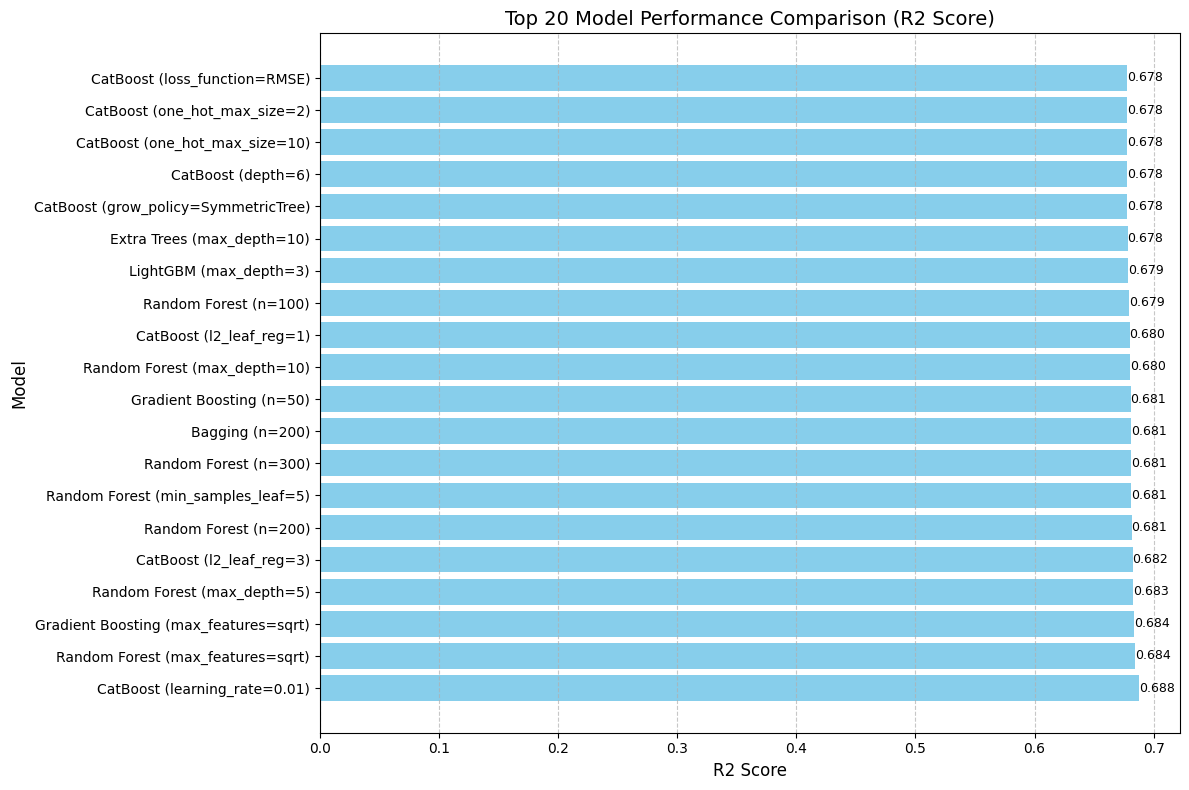

In [ ]:
# Call the visualization function
visualize_results(results_df)